# Exploring Trader Performance vs Market Sentiment
**Dataset:** Hyperliquid Historical Trades + Bitcoin Fear & Greed Index  
**Total Trades Analysed:** 211,224  
**Date Range:** 2024

## 1. Importing Libraries

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Libraries ready!")

Libraries ready!


## 2. Loading the Datasets

In [30]:
trader_df = pd.read_csv('historical_data.csv')
fear_greed_df = pd.read_csv('fear_greed_index.csv')

print("Trader data shape:", trader_df.shape)
print("Fear/Greed data shape:", fear_greed_df.shape)

print("\nTrader data columns:", trader_df.columns.tolist())
print("\nFear/Greed columns:", fear_greed_df.columns.tolist())


Trader data shape: (211224, 16)
Fear/Greed data shape: (2644, 4)

Trader data columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Fear/Greed columns: ['timestamp', 'value', 'classification', 'date']


## 3. Cleaning & Merging

In [31]:
print("=== TRADER DATA - First 3 rows ===")
print(trader_df.head(3))

print("\n=== FEAR/GREED DATA - First 3 rows ===")
print(fear_greed_df.head(3))

print("\n=== TRADER DATA - Basic Info ===")
print(trader_df.dtypes)

print("\n=== FEAR/GREED DATA - Basic Info ===")
print(fear_greed_df.dtypes)

print("\n=== Missing values in Trader data ===")
print(trader_df.isnull().sum())

print("\n=== Missing values in Fear/Greed data ===")
print(fear_greed_df.isnull().sum())

=== TRADER DATA - First 3 rows ===
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
1         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
2         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   

   Crossed       Fee      Trade ID     Tim

In [32]:
trader_df['date'] = pd.to_datetime(trader_df['Timestamp IST'], dayfirst=True).dt.date

fear_greed_df['date'] = pd.to_datetime(fear_greed_df['date']).dt.date

merged_df = pd.merge(trader_df, fear_greed_df[['date', 'value', 'classification']], on='date', how='left')

print("Merged data shape:", merged_df.shape)
print("\nFirst 3 rows:")
print(merged_df[['Account', 'Coin', 'Side', 'Closed PnL', 'date', 'value', 'classification']].head(3))

print("\nHow many trades matched with sentiment data:")
print(merged_df['classification'].value_counts())

print("\nUnmatched trades (no sentiment data):", merged_df['classification'].isnull().sum())

Merged data shape: (211224, 19)

First 3 rows:
                                      Account  Coin Side  Closed PnL  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  BUY         0.0   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  BUY         0.0   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  BUY         0.0   

         date  value classification  
0  2024-12-02   80.0  Extreme Greed  
1  2024-12-02   80.0  Extreme Greed  
2  2024-12-02   80.0  Extreme Greed  

How many trades matched with sentiment data:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

Unmatched trades (no sentiment data): 6


## 4. Sentiment Analysis

In [33]:
pnl_by_sentiment = merged_df.groupby('classification')['Closed PnL'].mean().sort_values(ascending=False)

print("=== Average Closed PnL by Sentiment ===")
print(pnl_by_sentiment)

print("\n=== Total Closed PnL by Sentiment ===")
print(merged_df.groupby('classification')['Closed PnL'].sum().sort_values(ascending=False))

print("\n=== Win Rate by Sentiment ===")
merged_df['is_win'] = merged_df['Closed PnL'] > 0
print(merged_df.groupby('classification')['is_win'].mean().sort_values(ascending=False))


=== Average Closed PnL by Sentiment ===
classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64

=== Total Closed PnL by Sentiment ===
classification
Fear             3.357155e+06
Extreme Greed    2.715171e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Extreme Fear     7.391102e+05
Name: Closed PnL, dtype: float64

=== Win Rate by Sentiment ===
classification
Extreme Greed    0.464943
Fear             0.420768
Neutral          0.396991
Greed            0.384828
Extreme Fear     0.370607
Name: is_win, dtype: float64


## 5. Visualisations

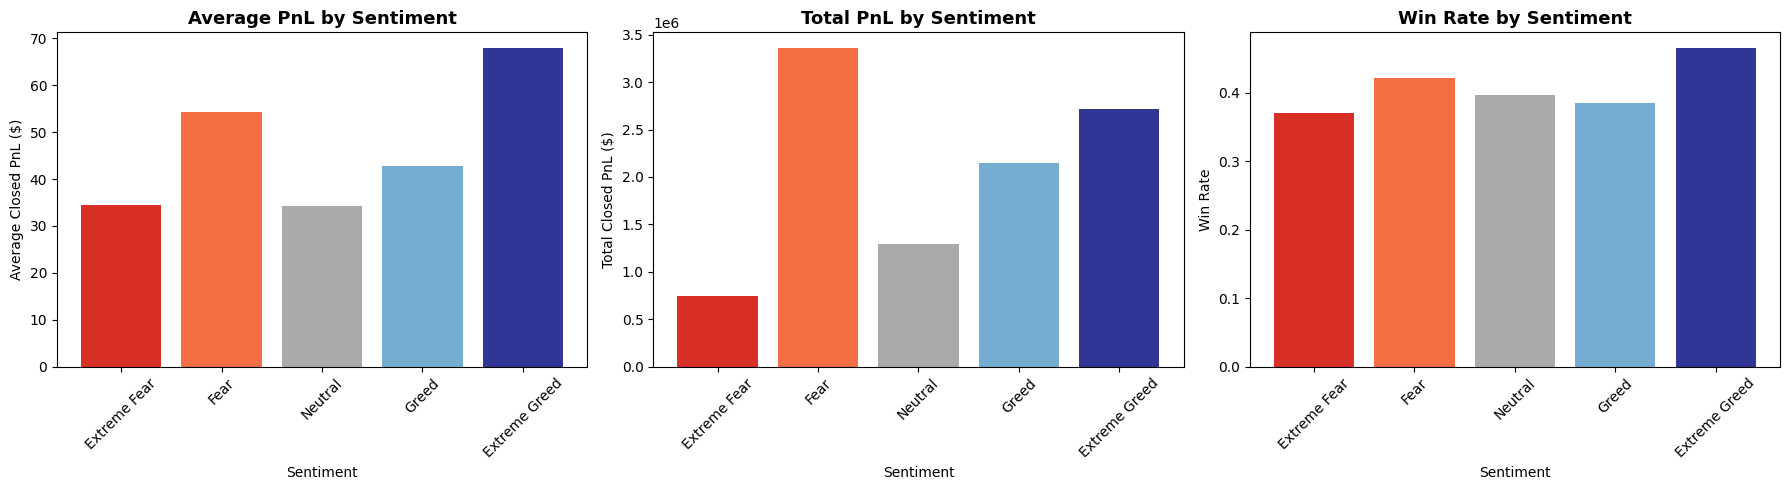

Chart saved!


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
colors = ['#d73027', '#f46d43', '#grey', '#74add1', '#313695']
colors = ['#d73027', '#f46d43', '#aaaaaa', '#74add1', '#313695']

avg_pnl = merged_df.groupby('classification')['Closed PnL'].mean().reindex(order)
axes[0].bar(order, avg_pnl.values, color=colors)
axes[0].set_title('Average PnL by Sentiment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Average Closed PnL ($)')
axes[0].tick_params(axis='x', rotation=45)

total_pnl = merged_df.groupby('classification')['Closed PnL'].sum().reindex(order)
axes[1].bar(order, total_pnl.values, color=colors)
axes[1].set_title('Total PnL by Sentiment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Total Closed PnL ($)')
axes[1].tick_params(axis='x', rotation=45)

win_rate = merged_df.groupby('classification')['is_win'].mean().reindex(order)
axes[2].bar(order, win_rate.values, color=colors)
axes[2].set_title('Win Rate by Sentiment', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Sentiment')
axes[2].set_ylabel('Win Rate')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

In [35]:
print(merged_df.columns.tolist())


['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'value', 'classification', 'is_win']


In [36]:
print("=== Average Trade Size (USD) by Sentiment ===")
print(merged_df.groupby('classification')['Size USD'].mean().reindex(order))

print("\n=== Buy vs Sell % by Sentiment ===")
print(pd.crosstab(merged_df['classification'], merged_df['Side'], normalize='index').reindex(order))

print("\n=== Average Fee by Sentiment ===")
print(merged_df.groupby('classification')['Fee'].mean().reindex(order))

print("\n=== Top 3 Coins per Sentiment ===")
for sentiment in order:
    top_coins = merged_df[merged_df['classification'] == sentiment]['Coin'].value_counts().head(3)
    print(f"\n{sentiment}:")
    print(top_coins)

=== Average Trade Size (USD) by Sentiment ===
classification
Extreme Fear     5349.731843
Fear             7816.109931
Neutral          4782.732661
Greed            5736.884375
Extreme Greed    3112.251565
Name: Size USD, dtype: float64

=== Buy vs Sell % by Sentiment ===
Side                 BUY      SELL
classification                    
Extreme Fear    0.510981  0.489019
Fear            0.489513  0.510487
Neutral         0.503343  0.496657
Greed           0.488559  0.511441
Extreme Greed   0.448590  0.551410

=== Average Fee by Sentiment ===
classification
Extreme Fear     1.116291
Fear             1.495172
Neutral          1.044798
Greed            1.254372
Extreme Greed    0.675902
Name: Fee, dtype: float64

=== Top 3 Coins per Sentiment ===

Extreme Fear:
Coin
HYPE    10278
SOL      1878
BTC      1765
Name: count, dtype: int64

Fear:
Coin
HYPE    27951
BTC      9870
@107     5462
Name: count, dtype: int64

Neutral:
Coin
HYPE    17324
BTC      4753
@107     4210
Name: count, dtyp

## 6. Top Trader Analysis

In [37]:
print("=== Top 10 Traders by Total PnL ===")
top_traders = merged_df.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)
print(top_traders)

print("\n=== Top 10 Traders by Win Rate (min 50 trades) ===")
trader_stats = merged_df.groupby('Account').agg(
    total_trades=('Closed PnL', 'count'),
    win_rate=('is_win', 'mean'),
    total_pnl=('Closed PnL', 'sum')
).query('total_trades >= 50').sort_values('win_rate', ascending=False).head(10)
print(trader_stats)

=== Top 10 Traders by Total PnL ===
Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

=== Top 10 Traders by Win Rate (min 50 trades) ===
                                            total_trades  win_rate  \
Account                                                              
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4          9893  0.810876   
0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0           417  0.573141   
0

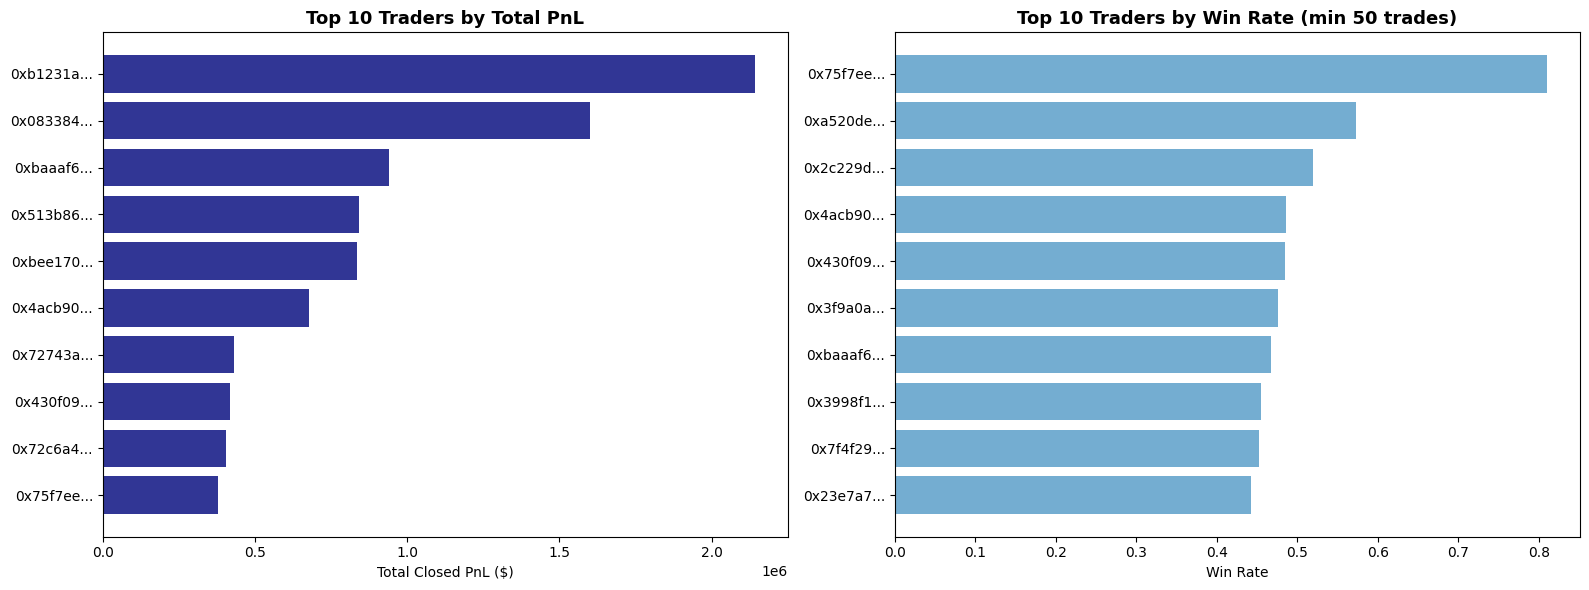

Chart saved!


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_traders_plot = top_traders.reset_index()
top_traders_plot['Account_short'] = top_traders_plot['Account'].str[:8] + '...'
axes[0].barh(top_traders_plot['Account_short'], top_traders_plot['Closed PnL'], color='#313695')
axes[0].set_title('Top 10 Traders by Total PnL', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Closed PnL ($)')
axes[0].invert_yaxis()

top_winrate_plot = trader_stats.reset_index().head(10)
top_winrate_plot['Account_short'] = top_winrate_plot['Account'].str[:8] + '...'
axes[1].barh(top_winrate_plot['Account_short'], top_winrate_plot['win_rate'], color='#74add1')
axes[1].set_title('Top 10 Traders by Win Rate (min 50 trades)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Win Rate')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('top_traders.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

In [39]:
best_trader = '0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4'
best_trader_df = merged_df[merged_df['Account'] == best_trader]

print("=== Best Trader Performance by Sentiment ===")
print(best_trader_df.groupby('classification').agg(
    total_trades=('Closed PnL', 'count'),
    win_rate=('is_win', 'mean'),
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum')
).reindex(order))

print("\n=== Best Trader Favourite Coins ===")
print(best_trader_df['Coin'].value_counts().head(5))

print("\n=== Best Trader Buy vs Sell ===")
print(best_trader_df['Side'].value_counts(normalize=True))

=== Best Trader Performance by Sentiment ===
                total_trades  win_rate    avg_pnl      total_pnl
classification                                                  
Extreme Fear             316  0.914557  81.243158   25672.838055
Fear                    1664  0.779447  29.666031   49364.275663
Neutral                 1464  0.715164  -1.780025   -2605.956471
Greed                   2618  0.807869  36.645300   95937.394195
Extreme Greed           3831  0.854607  55.005705  210726.855269

=== Best Trader Favourite Coins ===
Coin
JELLY      992
ZEREBRO    644
PURR       629
kBONK      447
ONDO       383
Name: count, dtype: int64

=== Best Trader Buy vs Sell ===
Side
SELL    0.501769
BUY     0.498231
Name: proportion, dtype: float64


# Trading Sentiment Analysis
## Key Insights & Recommendations

### Dataset Overview
- 211,224 trades from Hyperliquid
- Matched with daily Fear & Greed Index
- 5 sentiment categories: Extreme Fear, Fear, Neutral, Greed, Extreme Greed

---

### Insight 1: Extreme Greed = Best Quality Trades
- Highest average PnL per trade: $67.89
- Highest win rate: 46.5%
- Recommendation: Traders should focus on trade quality during Greed periods

### Insight 2: Fear = Most Activity, Most Total Profit
- Most trades happen during Fear (61,837 trades)
- Highest total profit: $3.35 million
- Traders put most money per trade during Fear ($7,816 avg)
- Recommendation: Stay active during Fear — volume and opportunity are highest

### Insight 3: Contrarian Behavior is Profitable
- During Extreme Fear: traders BUY more (51%) than SELL
- During Extreme Greed: traders SELL more (55%) than BUY
- This "buy fear, sell greed" behavior aligns with the most profitable outcomes
- Recommendation: Follow contrarian strategy — buy during fear, take profits during greed

### Insight 4: Neutral Markets are Dangerous
- Lowest average PnL: $34.31
- Even the best trader LOSES money during Neutral periods (-$2,606)
- Recommendation: Reduce trading activity during Neutral sentiment — risk/reward is poorest

### Insight 5: The Best Trader Teaches Us a Lot
- 0x75f7... achieves 81% overall win rate across 9,893 trades
- Best performance during Extreme Fear (91% win rate)
- Trades altcoins, not just BTC/ETH
- Perfectly balanced Buy/Sell ratio — no directional bias
- Recommendation: Study and replicate this trader's behavior during extreme sentiment periods

---

### Final Recommendation
The data strongly suggests traders should:
1. **Be most active during Fear and Extreme Greed** — best opportunities
2. **Buy during Fear, Sell during Greed** — contrarian strategy works
3. **Avoid or reduce trades during Neutral periods** — lowest returns
4. **Focus on altcoins during extreme sentiment** — highest volatility = highest opportunity for skilled traders